# My Methodology Behind Preprocessing

### <ins> Collect & Import Data </ins>

In [ ]:
from typing import Union

# Data Persistence tools
from pathlib import Path
import os
import json

# Data collection, processing & storing tools
import requests
from SECRETS import API_KEY, CHANNEL_ID
from sklearn.preprocessing import StandardScaler
import pandas

# Visualisation
import matplotlib.pyplot as plt


# CONSTANTS
JSON_OUT_DIR = "saves/assets_info/"
SEQUENCE_LEN = 20

API_MAX_RESULTS = 8000
OLDEST_DATE:str = "2002-02-28 00:00:00"

ASSET_NAME:str = "PD1"
__CACHE_PATH:str = f"./cache/{ASSET_NAME}"
"""Every asset stores cache to speed up processing in DT"""

__cache_cloud_paths:dict = {"root": f"{__CACHE_PATH}/cloud_data", "data_points": f"{__CACHE_PATH}/cloud_data/data_points", "meta":f"{__CACHE_PATH}/cloud_data/meta"}
   
def __data_collection() -> pandas.DataFrame:
        # 1. Check cache up-to-date
        if not os.path.isfile(__cache_cloud_paths["data_points"]):
            file_path = Path(__cache_cloud_paths["data_points"])
            file_path.parent.mkdir(parents=True, exist_ok=True)
            with open(file_path, "w") as f: f.close()

        cached_dps: pandas.DataFrame
        try:
            cached_dps = pandas.read_csv(__cache_cloud_paths["data_points"])
            cached_dps.index = cached_dps["created_at"]
            cached_dps.index = pandas.to_datetime(cached_dps.index, format="%Y-%m-%d %H:%M:%S")
            cached_dps.drop(columns=["created_at"], inplace=True)
        except pandas.errors.EmptyDataError:
            cached_dps = pandas.DataFrame()

        # 2. Download and cache the cloud data that's not cached already
        URL = f"https://thingspeak.mathworks.com/channels/{CHANNEL_ID}/feeds.json"
        API_payload:requests.Response
        if cached_dps.empty:
            API_payload = requests.get(URL, params={"api_key": API_KEY, "start":OLDEST_DATE})
        else:
            # Append additional dps on cloud to cache
            latest_cached_dp = str(cached_dps.tail(n=1).index[-1] + pandas.Timedelta(seconds=1)) # Add a second so it doesnt factor last row in request
            API_payload = requests.get(URL, params={"api_key": API_KEY, "start":latest_cached_dp, "results":API_MAX_RESULTS})

        data = API_payload.json()
        print(f"API Response: {API_payload.status_code}")
        
        # 3. If new data on cloud since last download, append to cache and dataframe
        features_df: pandas.DataFrame
        new_dps = pandas.DataFrame(data["feeds"])

        if not new_dps.empty:
            meta:dict = data["channel"]
            # get field names
            feature_fields = {}
            # 8 Fields
            for i in range(1, 8+1):
                if f"field{i}" in list(meta.keys()):
                    feature_fields.update({f"field{i}": meta[f"field{i}"]})

            new_dps.index = new_dps["created_at"]
            new_dps.index = pandas.to_datetime(new_dps.index, format="%Y-%m-%dT%H:%M:%SZ") # ThingSpeak Format

            # Rename ThingSpeak fields (field1, field2, etc) to feature names (RMS, Kurtosis, etc)
            new_dps.rename(columns=feature_fields, inplace=True)
            new_dps.drop(columns=["created_at", "entry_id"], inplace=True)
            
            # Concatenate cached & cloud datapoints
            features_df = pandas.concat([cached_dps, new_dps])
            # Update cache
            features_df.to_csv(__cache_cloud_paths["data_points"])

        else: # Else, just use cache
            features_df = cached_dps
            print("No new datapoints sinced cached")
        
        return features_df


df = __data_collection()

API Response: 200
No new datapoints sinced cached


#### Visualisation

In [10]:
UNIFED_PLOT = False

def plot(df:Union[pandas.DataFrame, pandas.Series], columns_unified:bool=UNIFED_PLOT) -> None:
    if UNIFED_PLOT or isinstance(df, pandas.Series):
        df.plot()
    else:
        COLS_C = 2
        cols_count = len(df.columns)
        ROWS_C = int(cols_count/COLS_C)
        
        df.plot(
            subplots=True,
            layout=(ROWS_C, COLS_C),  # 2 rows, 2 columns
            figsize=(10, 8),  # Width, height in inches
            sharex=True,  # Optional: share the same x-axis
            sharey=False,  # Optional: unique y-axis scales for each column
            title="DataFrame Columns Grid",
        )

        plt.tight_layout()  # Fixes overlapping text/labels
    plt.show()

#### Preview

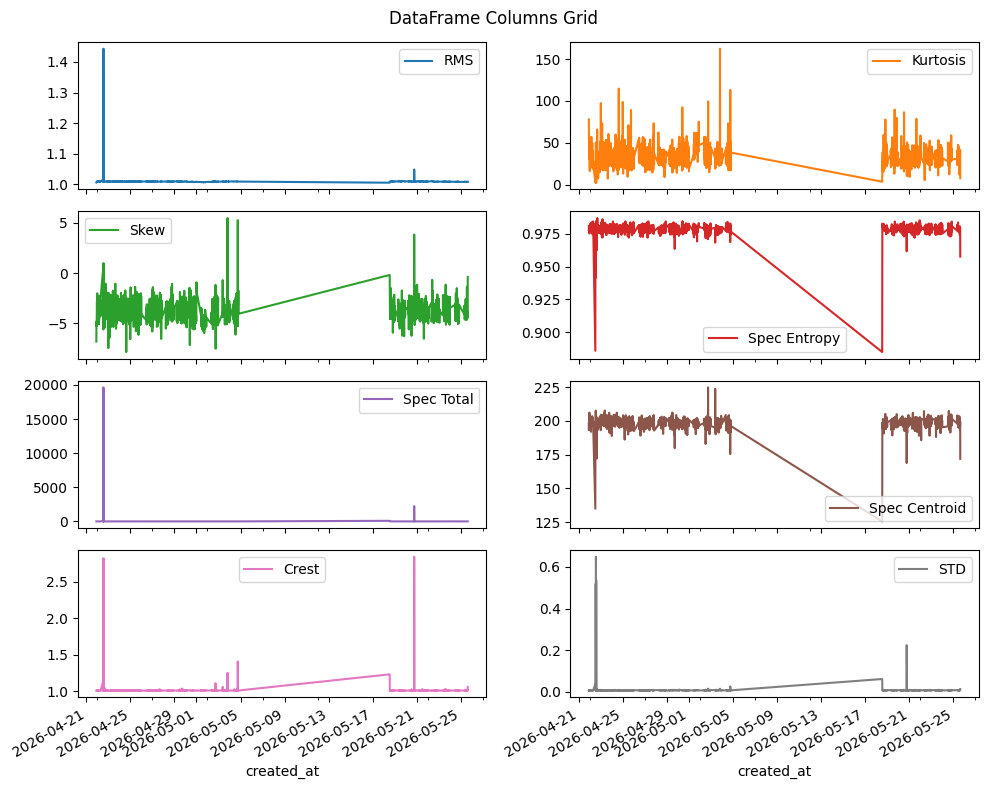

In [27]:
plot(df)

### <ins> Preprocessing </ins>

#### 1. Remove Outliers



--------------------RMS's upper threshold: 1.00981 

Before clip: Avg=1.0100191423357663    Std=0.018545584160077656    Upper=1.44348   Lower=1.00526
After clip: Avg=1.0089441268248176    Std=0.0005281319922921237    Upper=1.00981    Lower=1.0077814999999999
Series([], Name: RMS, dtype: float64)


--------------------Kurtosis's upper threshold: 50.080473000000005 

Before clip: Avg=33.6487300243309    Std=10.98303526231789    Upper=162.39166   Lower=2.33233
After clip: Avg=33.263339100364966    Std=7.950410980946501    Upper=50.080473000000005    Lower=19.961614000000004
Series([], Name: Kurtosis, dtype: float64)


--------------------Skew's upper threshold: -2.296706 

Before clip: Avg=-3.810160918491484    Std=0.978221171884402    Upper=5.46087   Lower=-7.85227
After clip: Avg=-3.8353399960462284    Std=0.7442067699231013    Upper=-2.296706    Lower=-5.081578499999999
Series([], Name: Skew, dtype: float64)


--------------------Spec Entropy's upper threshold: 0.9821885 

Before cli

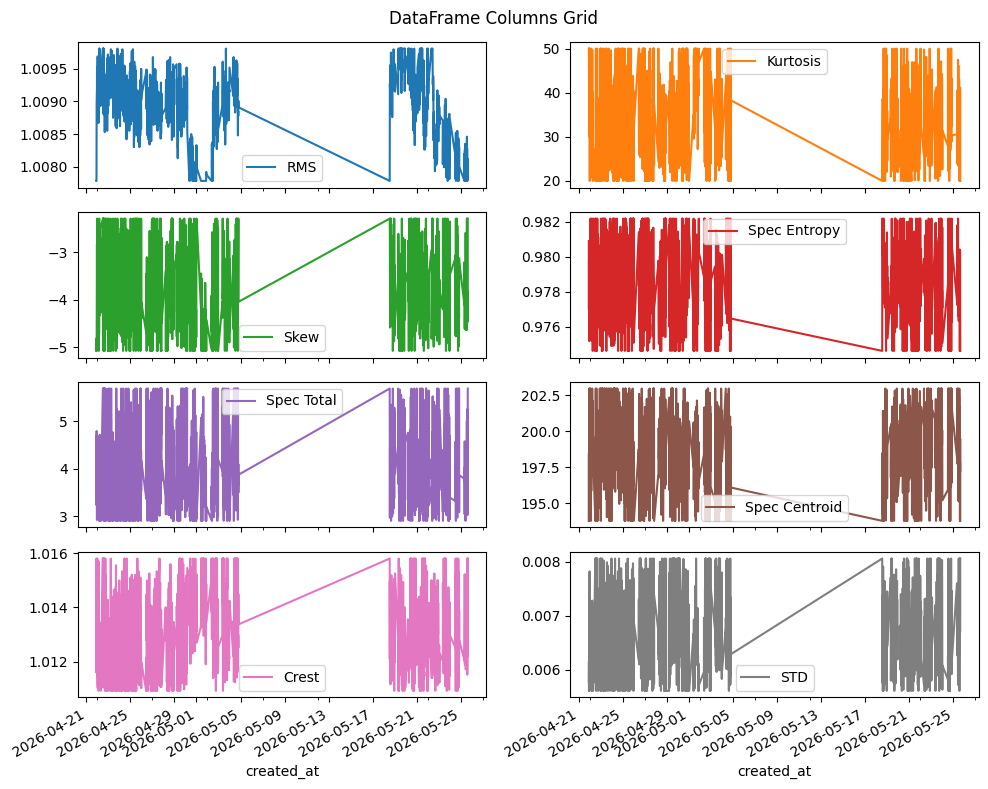

In [30]:
REMOVE_OUTLIERS = True

UPPER_PERCENTILE_CLIP: float = .95
LOWER_PERCENTILE_CLIP: float = 1-UPPER_PERCENTILE_CLIP  # Equal percentile clipping.    (95% means upper 5% & lower 5% clipped)
clipped_df:pandas.Series = df.copy()

if REMOVE_OUTLIERS:
    for feature in df.columns:
        # Clip upper outliers for each feature
        # Clip DOESNT REMOVE datapoints (dps), it changes to dps outside boundaries to boundary wall value
        # Effectively bringing outliers closer to average data without removing & losing the pattern.


        upper_threshold:float = clipped_df[feature].quantile(UPPER_PERCENTILE_CLIP)
        lower_threshold:float = clipped_df[feature].quantile(LOWER_PERCENTILE_CLIP)

        print(f"\n\n--------------------{feature}'s upper threshold: {upper_threshold} \n")
        print(f"Before clip: Avg={clipped_df[feature].mean()}    Std={clipped_df[feature].std()}    Upper={clipped_df[feature].max()}   Lower={clipped_df[feature].min()}")
        
        clipped_df[feature] = clipped_df[feature].clip(upper=upper_threshold, lower=lower_threshold)
        
        print(f"After clip: Avg={clipped_df[feature].mean()}    Std={clipped_df[feature].std()}    Upper={clipped_df[feature].max()}    Lower={clipped_df[feature].min()}")
        print(clipped_df[feature][clipped_df[feature] > upper_threshold])



plot(clipped_df)

#### ~~2. Filling Missing Datapoints~~

This is no longer used. Data is sequenced instead, taking short snippets of continguous datapoints  

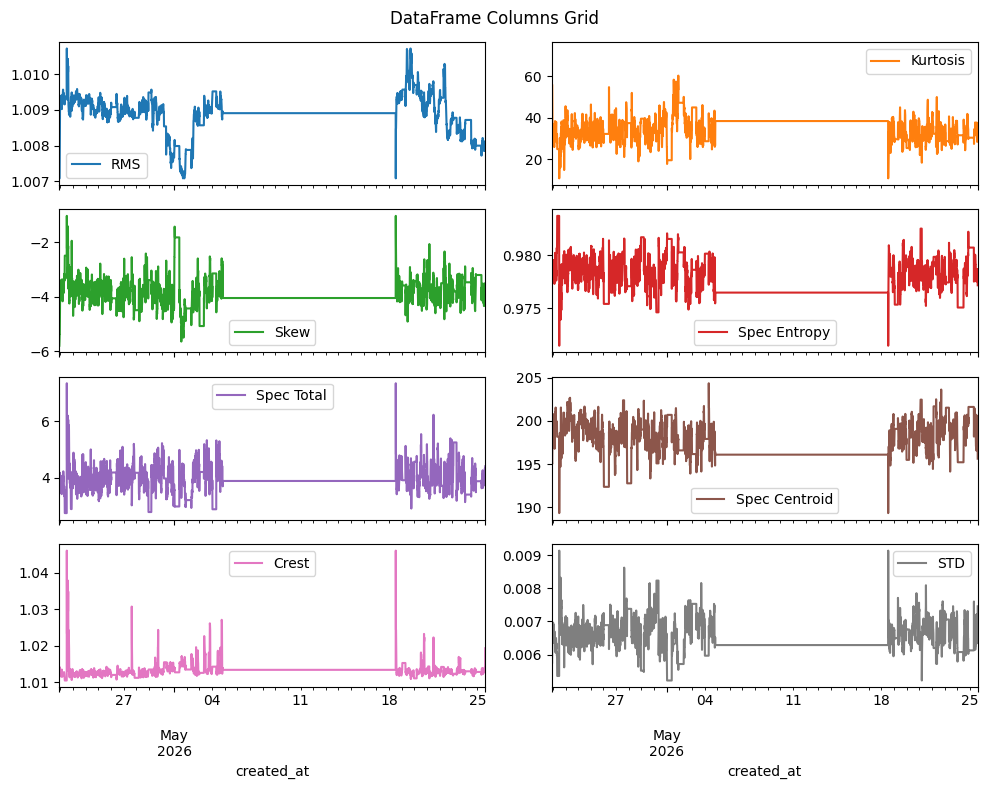

In [29]:
filled_df:pandas.Series = clipped_df.copy()
filled_df.index = filled_df.index.floor("10min")
filled_df = filled_df.groupby(filled_df.index).mean()

resampled_df = filled_df.resample("10min").asfreq()
rolling_df = resampled_df.rolling(window=6, min_periods=1).mean()
filled_avg_df = rolling_df.ffill()

plot(filled_avg_df)

#### 2. Segment Datapoints (Sequences)

Rather than trying to fill in excessive missing data (even when averaging it distorts the pattern) instead parts of the data which is not suitable contigous (containing a gap) is just ignored. The training data is segmented into sequences of suitably contingous chunks; These sequences contain the correct pattern over a short amount of time (with no excessive jump in time).

Sequence Extraction Example:
12:10 -> 12:20 -> 12:30 -> 12:40 -> 12:50 -> 13:00 -> 13:10  -> 14:40 -> 14:50 -> 15:00 

**Segmenting** 

<p style="color:green">12:10 -> 12:20 -> 12:30 </p> 

<p style="color:green">12:40 -> 12:50 -> 13:00 </p> 

<p style="color:red">13:10 -> 14:40 -> 14:50 </p>   -   Disregard, not contigous to <30min interval 

In [ ]:
SESSION_GAP_LIMIT = 30  # Minutes
MIN_CONSECATIVE = 20

session_df:pandas.Series = clipped_df.copy()

time_diffs = clipped_df.index.to_series().diff()
sessions = time_diffs > pandas.Timedelta(minutes=SESSION_GAP_LIMIT)
# Where true (session is broken here as gap is larger then limit) increment 1 (true=1)
session_df["SessionID"] = sessions.cumsum()
if False:
    plot(session_df["SessionID"])

# occurances = Count of occurances of sessionID  
# Remove dps where occurances < x   (keeping sequences that has x consecuative & uninterupted dps)

session_remove_mask = session_df["SessionID"].value_counts(sort=True) > MIN_CONSECATIVE

valid_session_ids:list = session_remove_mask[session_remove_mask].index.to_list()
invalid_sessions = session_remove_mask[session_remove_mask == False] # Just for testing

valid_sessions = session_df[session_df["SessionID"].isin(valid_session_ids)]
print(f"Valid Sessions Kept: {valid_sessions['SessionID'].unique()}")


# Now split large sessions into chunks of session_chunk_size (chunk=30, session_count=60, then chunks_count=2)
#session_chunk_counts:pandas.Series = valid_sessions["SessionID"].value_counts(sort=True)
sessions_chunks_count:pandas.Series = valid_sessions["SessionID"].value_counts(sort=True) // MIN_CONSECATIVE  # // floor division
print(sessions_chunks_count)
#plot(valid_sessions["SessionID"])

for session_id in valid_sessions['SessionID'].unique():
    print(session_id)

# session_id_count = 0
# session_id = valid_sessions.iterrows()[0]
# for ts, df in valid_sessions.iterrows():
#     if df["SesssionID"] != session_id:
#         session_id_count = 0
#         session_id = df["SessionID"]
#     print(df["SessionID"])

Valid Sessions Kept: [ 0  4  5  7  8  9 13 14 15 18 20 27 28 29 30 31 32 33 36 38 40 41 42 43
 45]
SessionID
4     14
5      5
38     5
7      4
36     4
42     4
29     3
20     2
30     2
0      2
31     2
43     2
27     1
8      1
41     1
40     1
28     1
45     1
33     1
18     1
13     1
9      1
32     1
15     1
14     1
Name: count, dtype: int64


In [65]:
print(invalid_sessions)
session_df.loc[session_df["SessionID"] == 16].count()

SessionID
19    False
3     False
16    False
1     False
12    False
21    False
17    False
35    False
44    False
23    False
37    False
34    False
6     False
25    False
22    False
24    False
26    False
11    False
39    False
2     False
10    False
Name: count, dtype: bool


RMS              16
Kurtosis         16
Skew             16
Spec Entropy     16
Spec Total       16
Spec Centroid    16
Crest            16
STD              16
SessionID        16
dtype: int64